In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import requests


## Data loading

In [4]:
url = f'https://dummyjson.com/users?limit=100'
response = requests.get(url)

data_json = response.json()['users']

data = pd.DataFrame(data_json)

raw_data = data.to_csv('raw_data.csv', index=False)

## Data Exploration

#### shape of the dataframe (rows, columns)

In [3]:
print(data.shape)

(100, 28)


#### List of all column names

In [4]:
for i in data.columns:
    print(i)

id
firstName
lastName
maidenName
age
gender
email
phone
username
password
birthDate
image
bloodGroup
height
weight
eyeColor
hair
ip
address
macAddress
university
bank
company
ein
ssn
userAgent
crypto
role


#### Data types of each column

In [5]:
for i in data.columns:
    print(f"{i}: {data[i].dtype}")

id: int64
firstName: object
lastName: object
maidenName: object
age: int64
gender: object
email: object
phone: object
username: object
password: object
birthDate: object
image: object
bloodGroup: object
height: float64
weight: float64
eyeColor: object
hair: object
ip: object
address: object
macAddress: object
university: object
bank: object
company: object
ein: object
ssn: object
userAgent: object
crypto: object
role: object


#### Number of missing values per column

In [6]:
print(data.isnull().sum())

id            0
firstName     0
lastName      0
maidenName    0
age           0
gender        0
email         0
phone         0
username      0
password      0
birthDate     0
image         0
bloodGroup    0
height        0
weight        0
eyeColor      0
hair          0
ip            0
address       0
macAddress    0
university    0
bank          0
company       0
ein           0
ssn           0
userAgent     0
crypto        0
role          0
dtype: int64


#### Number of duplicate rows

In [7]:
print(data.astype(str).duplicated().sum())

0


#### Summary statistics for numeric columns

In [8]:
print(data.describe())

               id         age      height    weight
count  100.000000  100.000000  100.000000  100.0000
mean    50.500000   31.700000  176.392500   75.0431
std     29.011492    4.132893   13.838342   14.0146
min      1.000000   23.000000  150.250000   50.1000
25%     25.750000   28.750000  166.700000   63.0075
50%     50.500000   31.000000  178.320000   75.4600
75%     75.250000   34.000000  187.617500   87.5175
max    100.000000   46.000000  199.620000   98.7700


#### Value counts for important categorical columns (e.g. gender, bloodGroup, eyeColor, role, address.country)

In [9]:
print(data['gender'].value_counts())
print(data['bloodGroup'].value_counts())
print(data['eyeColor'].value_counts())
print(data['role'].value_counts())
print(data['address'].apply(lambda x: x['country']).value_counts())

gender
female    52
male      48
Name: count, dtype: int64
bloodGroup
O-     19
A+     15
AB+    13
AB-    13
B+     12
B-     10
O+     10
A-      8
Name: count, dtype: int64
eyeColor
Brown     18
Hazel     16
Gray      14
Red       12
Blue      12
Green     11
Amber     10
Violet     7
Name: count, dtype: int64
role
user         85
moderator    10
admin         5
Name: count, dtype: int64
address
United States    100
Name: count, dtype: int64


## Data Cleaning

#### If any important column is missing (e.g. country), extract it from nested columns like address using .apply() and json.loads if necessary

In [ ]:
address_df = pd.json_normalize(data['address'])
hair_df = pd.json_normalize(data['hair'])
bank_df = pd.json_normalize(data['bank'])
company_df = pd.json_normalize(data['company'])
crypto_df = pd.json_normalize(data['crypto'])

In [11]:
address_df

,address,city,state,stateCode,postalCode,country,coordinates.lat,coordinates.lng
0,626 Main Street,Phoenix,Mississippi,MS,29112,United States,-77.162130,-92.084824
1,385 Fifth Street,Houston,Alabama,AL,38807,United States,22.815468,115.608581
2,1642 Ninth Street,Washington,Alabama,AL,32822,United States,45.289366,46.832664
3,238 Jefferson Street,Seattle,Pennsylvania,PA,68354,United States,16.782513,-139.347230
4,607 Fourth Street,Jacksonville,Colorado,CO,26593,United States,0.505589,-157.432810
...,...,...,...,...,...,...,...,...
95,1140 Adams Street,Dallas,Minnesota,MN,29004,United States,83.417744,-7.933044
96,1948 Jefferson Street,Charlotte,Vermont,VT,12263,United States,52.294653,-70.699360
97,1577 Jefferson Street,Seattle,Montana,MT,41818,United States,88.607515,92.692781
98,1898 Second Street,Houston,Mississippi,MS,85234,United States,70.915423,-30.195987


In [12]:
hair_df

,color,type
0,Brown,Curly
1,Green,Straight
2,White,Wavy
3,Blonde,Straight
4,White,Straight
...,...,...
95,Green,Wavy
96,Green,Wavy
97,Blue,Wavy
98,Black,Straight


In [13]:
bank_df

,cardExpire,cardNumber,cardType,currency,iban
0,05/28,3693233511855044,Diners Club International,GBP,GB74MH2UZLR9TRPHYNU8F8
1,01/30,3530633803003665,JCB,USD,DE26362283149158045865
2,10/27,6011212053392887,Discover,EUR,DE12191213468288004835
3,07/30,5303440212268149,Mastercard,CAD,DE01300746880579852937
4,07/30,5237188057591130,Mastercard,NZD,DE19182355652037133559
...,...,...,...,...,...
95,07/29,5480171454066942,Mastercard,GBP,GB36C9TE2MIXX12X8IJMLG
96,11/27,6011597179762975,Discover,USD,DE16654874987771550206
97,10/29,348500223799446,American Express,JPY,DE94679076797491453575
98,03/27,3581201445671725,JCB,CAD,DE01439050186894663094


In [14]:
company_df

,department,name,title,address.address,address.city,address.state,address.stateCode,address.postalCode,address.coordinates.lat,address.coordinates.lng,address.country
0,Engineering,"Dooley, Kozey and Cronin",Sales Manager,263 Tenth Street,San Francisco,Wisconsin,WI,37657,71.814525,-161.150263,United States
1,Support,Spinka - Dickinson,Support Specialist,395 Main Street,Los Angeles,New Hampshire,NH,73442,79.098326,-119.624845,United States
2,Research and Development,Schiller - Zieme,Accountant,1896 Washington Street,Dallas,Nevada,NV,88511,20.086743,-34.577107,United States
3,Support,Pagac and Sons,Research Analyst,1622 Lincoln Street,Fort Worth,Pennsylvania,PA,27768,54.911930,-79.498328,United States
4,Human Resources,Graham - Gulgowski,Quality Assurance Engineer,1460 Sixth Street,San Antonio,Idaho,ID,21965,44.346545,-26.944701,United States
...,...,...,...,...,...,...,...,...,...,...,...
95,Product Management,Hudson - Marquardt,Chief Information Officer,164 Fifth Street,Indianapolis,New York,NY,27958,89.270633,-72.618747,United States
96,Legal,Luettgen and Sons,Support Specialist,1127 Oak Street,Chicago,Alabama,AL,37894,28.080301,-6.017825,United States
97,Training,Mayer - Smitham,Accountant,767 Adams Street,Phoenix,Washington,WA,13037,76.372465,24.919329,United States
98,Marketing,"Strosin, Anderson and Baumbach",Support Specialist,903 First Street,San Diego,Iowa,IA,87476,-47.007951,86.840506,United States


In [15]:
crypto_df

,coin,wallet,network
0,Bitcoin,0xb9fc2fe63b2a6c003f1c324c3bfa53259162181a,Ethereum (ERC20)
1,Bitcoin,0xb9fc2fe63b2a6c003f1c324c3bfa53259162181a,Ethereum (ERC20)
2,Bitcoin,0xb9fc2fe63b2a6c003f1c324c3bfa53259162181a,Ethereum (ERC20)
3,Bitcoin,0xb9fc2fe63b2a6c003f1c324c3bfa53259162181a,Ethereum (ERC20)
4,Bitcoin,0xb9fc2fe63b2a6c003f1c324c3bfa53259162181a,Ethereum (ERC20)
...,...,...,...
95,Bitcoin,0xb9fc2fe63b2a6c003f1c324c3bfa53259162181a,Ethereum (ERC20)
96,Bitcoin,0xb9fc2fe63b2a6c003f1c324c3bfa53259162181a,Ethereum (ERC20)
97,Bitcoin,0xb9fc2fe63b2a6c003f1c324c3bfa53259162181a,Ethereum (ERC20)
98,Bitcoin,0xb9fc2fe63b2a6c003f1c324c3bfa53259162181a,Ethereum (ERC20)


#### adding relevant columns to the main df

In [6]:
data['city'] = address_df['city'].fillna('Unknown')
data['country'] = address_df['country'].fillna('Unknown')
data['hair_color'] = hair_df['color'].fillna('Unknown')
data['cardType'] = bank_df['cardType'].fillna('Unknown')
data['company_name'] = company_df['name'].fillna('Unknown')
data['job_title'] = company_df['title'].fillna('Unknown')
data['crypto_coin'] = crypto_df['coin'].fillna('Unknown')

data.drop(columns=['address', 'hair', 'bank', 'company', 'crypto'], inplace=True)

In [7]:
data

,id,firstName,lastName,maidenName,age,gender,email,phone,username,password,...,ssn,userAgent,role,city,country,hair_color,cardType,company_name,job_title,crypto_coin
0,1,Emily,Johnson,Smith,29,female,emily.johnson@x.dummyjson.com,+81 965-431-3024,emilys,emilyspass,...,900-590-289,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,admin,Phoenix,United States,Brown,Diners Club International,"Dooley, Kozey and Cronin",Sales Manager,Bitcoin
1,2,Michael,Williams,,36,male,michael.williams@x.dummyjson.com,+49 258-627-6644,michaelw,michaelwpass,...,108-953-962,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,admin,Houston,United States,Green,JCB,Spinka - Dickinson,Support Specialist,Bitcoin
2,3,Sophia,Brown,,43,female,sophia.brown@x.dummyjson.com,+81 210-652-2785,sophiab,sophiabpass,...,638-461-822,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,admin,Washington,United States,White,Discover,Schiller - Zieme,Accountant,Bitcoin
3,4,James,Davis,,46,male,james.davis@x.dummyjson.com,+49 614-958-9364,jamesd,jamesdpass,...,116-951-314,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,admin,Seattle,United States,Blonde,Mastercard,Pagac and Sons,Research Analyst,Bitcoin
4,5,Emma,Miller,Johnson,31,female,emma.miller@x.dummyjson.com,+91 759-776-1614,emmaj,emmajpass,...,526-210-885,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:9...,admin,Jacksonville,United States,White,Mastercard,Graham - Gulgowski,Quality Assurance Engineer,Bitcoin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,Aurora,Lawson,,27,female,aurora.lawson@x.dummyjson.com,+92 802-452-4192,auroral,auroralpass,...,191-532-292,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:9...,user,Dallas,United States,Green,Mastercard,Hudson - Marquardt,Chief Information Officer,Bitcoin
96,97,Oscar,Powers,,34,male,oscar.powers@x.dummyjson.com,+61 929-572-1408,oscarp,oscarppass,...,856-795-126,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,user,Charlotte,United States,Green,Discover,Luettgen and Sons,Support Specialist,Bitcoin
97,98,Clara,Berry,,31,female,clara.berry@x.dummyjson.com,+1 390-831-5172,clarab,clarabpass,...,625-638-955,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,user,Seattle,United States,Blue,American Express,Mayer - Smitham,Accountant,Bitcoin
98,99,Gavin,Stanley,,33,male,gavin.stanley@x.dummyjson.com,+44 466-358-6026,gavins,gavinspass,...,321-561-524,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,user,Houston,United States,Black,JCB,"Strosin, Anderson and Baumbach",Support Specialist,Bitcoin


#### Handle missing values in age, height, weight

In [ ]:
data['age'].isnull().sum()
data['height'].isnull().sum()
data['weight'].isnull().sum()

0

##### No missing values detected. however, if future data contain null values we can run this code to fill it

In [19]:
data['age'] = data['age'].fillna(data['age'].mean())
data['height'] = data['height'].fillna(data['height'].mean())
data['weight'] = data['weight'].fillna(data['weight'].mean())

#### saving the cleaned dataframe

In [12]:
data.to_csv('cleaned_data.csv', index=False)

## Data Analysis

#### What is the average age of users?

In [ ]:
avg_age = data['age'].mean()
avg_age

31.7

#### Average age by gender?

gender
female    29.730769
male      33.833333
Name: age, dtype: float64


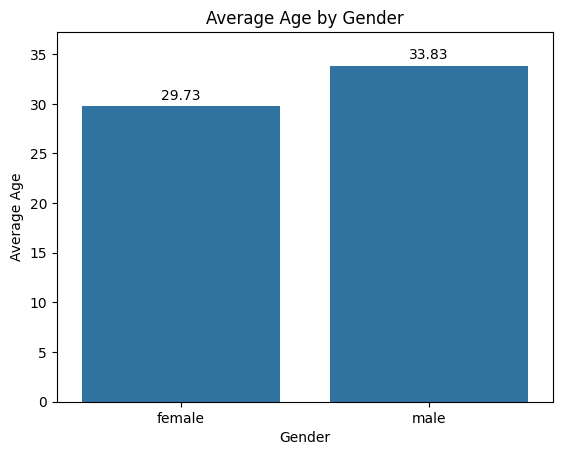

In [ ]:
avg_by_gender = data.groupby('gender')['age'].mean()
print(avg_by_gender)


ax = sns.barplot(x=avg_by_gender.index, y=avg_by_gender.values)

ax.bar_label(ax.containers[0], fmt='%.2f', padding=3)

plt.ylim(0, avg_by_gender.max() * 1.1)

plt.title('Average Age by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Age')
plt.show()

#### Number of users per gender?

gender
female    52
male      48
Name: count, dtype: int64


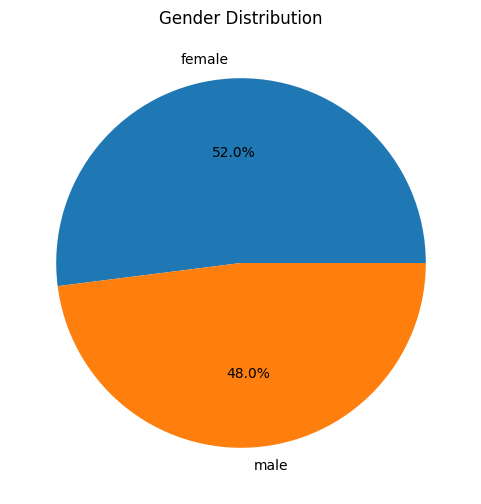

In [ ]:
print(data['gender'].value_counts())


plt.figure(figsize=(6,6))
plt.pie(data['gender'].value_counts(), labels=data['gender'].value_counts().index, autopct='%1.1f%%')
plt.title('Gender Distribution')
plt.show()

#### Top 10 cities with the most users?

city
Phoenix         9
Jacksonville    8
Dallas          8
Columbus        8
San Diego       6
Chicago         6
Seattle         5
San Antonio     5
New York        5
Denver          5
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_12552\1995780287.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cities.index, y=top_cities.values, palette='viridis')


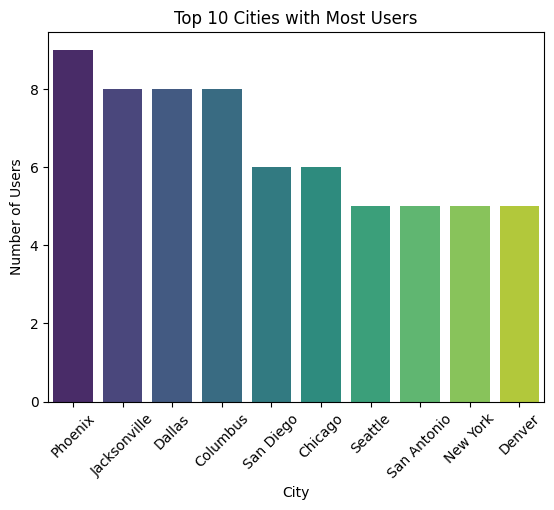

In [ ]:
top_cities = data['city'].value_counts().head(10)
print(top_cities)


sns.barplot(x=top_cities.index, y=top_cities.values, palette='viridis')
plt.xticks(rotation=45)
plt.xlabel('City')
plt.ylabel('Number of Users')
plt.title('Top 10 Cities with Most Users')
plt.show()


#### Average height and weight overall?

Average height: 176.39249999999996
Average weight: 75.04310000000001


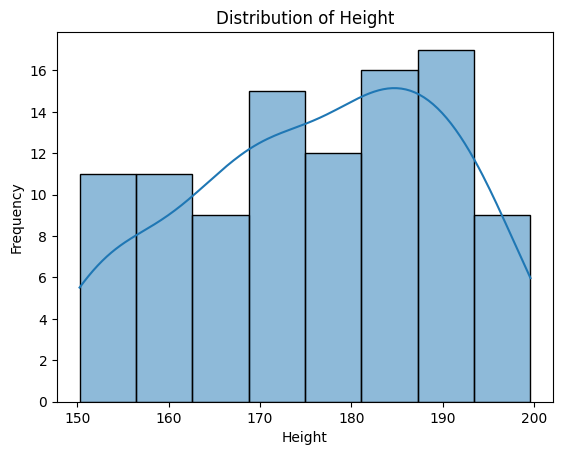

In [ ]:
avg_height = data['height'].mean()
avg_weight = data['weight'].mean()
print("Average height:", avg_height)
print("Average weight:", avg_weight)


sns.histplot(data['height'], kde=True)
plt.title('Distribution of Height')
plt.xlabel('Height')
plt.ylabel('Frequency')
plt.show()

#### Is there any obvious relationship between age and height/weight?

In [25]:
correlation = data['age'].corr(data['height'])
print(f"Correlation: {correlation}")

Correlation: -0.10217948263753567


<Axes: xlabel='age', ylabel='height'>

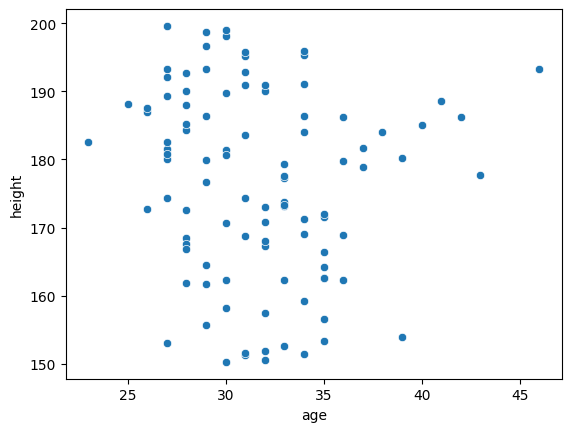

In [26]:
sns.scatterplot(x='age', y='height', data=data)


No significant correlation between the two attributes was found

#### Most used card type

In [16]:
most_used_card = data['cardType'].value_counts()
print(most_used_card)

cardType
Mastercard                   20
Diners Club International    16
Discover                     15
Visa                         14
American Express             13
UnionPay                     12
JCB                          10
Name: count, dtype: int64


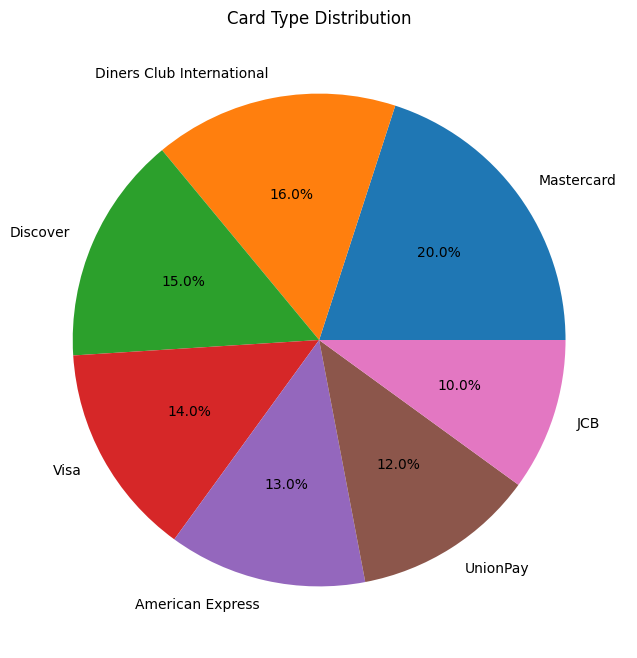

In [ ]:
plt.figure(figsize=(8,8))
plt.pie(most_used_card.values, labels=most_used_card.index, autopct='%1.1f%%')
plt.title('Card Type Distribution')
plt.show()

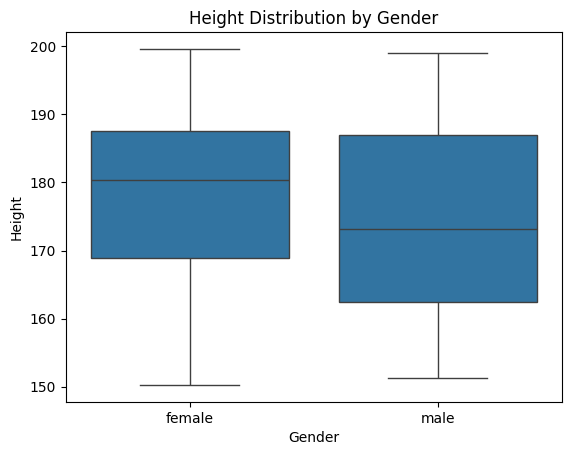

In [ ]:
sns.boxplot(x='gender', y='height', data=data)
plt.title('Height Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Height')
plt.show()

Analysis shows that the median height for females is considerably higher than that of the males which hints at possible data inaccuracies or inadequate sample size